# Fake News Detection on LIAR2

This notebook compares **classical machine learning models** and a **deep learning model** for binary fake news detection.

The dataset is based on **LIAR2**, and the original labels are converted into a binary task:

- `0, 1, 2 -> fake`
- `3, 4, 5 -> true`

The notebook is organized in the following way:

1. Load and inspect the data
2. Build the input features
3. Train and tune classical models
4. Fine-tune DistilBERT
5. Compare all models on the same task


In [ ]:
from __future__ import annotations

import gc
import inspect
import json
import random
import re
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_DIR = Path(".")
OUTPUT_DIR = Path("model_outputs_notebook")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BASE_URL = "https://raw.githubusercontent.com/chengxuphd/liar2/main/liar2"
SPLIT_TO_FILENAME = {
    "train": "train.csv",
    "validation": "valid.csv",
    "test": "test.csv",
}

TEXT_COLUMNS = [
    "statement",
    "context",
    "subject",
    "speaker",
    "state_info",
]

NUMERIC_COLUMNS = [
    "true_counts",
    "mostly_true_counts",
    "half_true_counts",
    "mostly_false_counts",
    "false_counts",
    "pants_on_fire_counts",
    "year",
    "month",
]

INCLUDE_SPEAKER_DESCRIPTION = False
INCLUDE_JUSTIFICATION = False
INCLUDE_NUMERIC_HISTORY_IN_TRANSFORMER_TEXT = True

CLASSICAL_SEARCH_ITERATIONS = 24
CLASSICAL_CV_FOLDS = 5
CLASSICAL_SEARCH_N_JOBS = -1
CLASSICAL_SEARCH_VERBOSE = 1

TFIDF_MAX_FEATURES = 50_000
TFIDF_NGRAM_RANGE = (1, 2)
TFIDF_MIN_DF = 2
TFIDF_SUBLINEAR_TF = True

TRANSFORMER_MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 384
TRANSFORMER_EPOCHS = 2
TRANSFORMER_LEARNING_RATE = 2e-5
TRANSFORMER_WEIGHT_DECAY = 0.01
TRANSFORMER_BATCH_SIZE = 16

print("Configuration loaded successfully.")
print(f"Transformer model: {TRANSFORMER_MODEL_NAME}")
print(f"TF-IDF max_features: {TFIDF_MAX_FEATURES}")

Configuration loaded successfully.
Transformer model: distilbert-base-uncased
TF-IDF max_features: 50000


## Feature selection and information leakage

Some input fields are intentionally disabled by default in order to avoid information leakage and to preserve a more realistic prediction setting.

The option `INCLUDE_JUSTIFICATION = False` is kept disabled because the `justification` field is often very close to the fact-checking explanation itself. In practice, this means that it may reveal information strongly related to the final label, making the task artificially easier.

The option `INCLUDE_SPEAKER_DESCRIPTION = False` is also disabled by default because the speaker description may contain information that became available only after the original statement was made. This introduces temporal leakage, since the model would be using information that would not have been causally available at prediction time.

In contrast, `INCLUDE_NUMERIC_HISTORY_IN_TRANSFORMER_TEXT = True` is enabled because the historical numerical counts provide useful contextual information about the speaker’s previous factual record. These values are therefore kept as part of the transformer input.


### Effect of information leakage

Enabling the leakage-prone fields produced a clear performance increase. On average, accuracy improved by roughly **8%**, with some test results improving by nearly **10%**. This gain should not be interpreted as a true modeling improvement, since it is explained by information leakage.

## Model configuration and hyperparameters

For the classical models, hyperparameter optimization is performed with randomized search and stratified cross-validation. The search uses `24` sampled configurations and `5` cross-validation folds, balancing model selection quality with computational cost.

The TF-IDF representation used by the classical models is controlled by four main parameters. `TFIDF_MAX_FEATURES = 50,000` limits the vocabulary size, `TFIDF_NGRAM_RANGE = (1, 2)` includes both unigrams and bigrams, `TFIDF_MIN_DF = 2` removes extremely rare terms, and `TFIDF_SUBLINEAR_TF = True` applies a logarithmic scaling to term frequency. Together, these choices help produce a compact but informative sparse representation of the text.

For the deep learning model, the selected configuration uses `distilbert-base-uncased` with `MAX_LENGTH = 384`, `TRANSFORMER_EPOCHS = 2`, `TRANSFORMER_LEARNING_RATE = 2e-5`, `TRANSFORMER_WEIGHT_DECAY = 0.01`, and `TRANSFORMER_BATCH_SIZE = 16`. These values were chosen after testing several combinations of key hyperparameters. In particular, the tuning explored learning rates `[1e-5, 2e-5, 3e-5]`, numbers of epochs `[2, 3, 4]`, and maximum sequence lengths `[128, 256, 384]`. The final configuration corresponds to the combination that achieved the best overall validation performance during tuning.

## Step 1 — Download and load the dataset

This cell checks whether the CSV files already exist locally.

If they do not exist, they are downloaded automatically from the LIAR2 repository https://github.com/chengxuphd/liar2/tree/main/liar2.

Then the three splits are loaded:

- training
- validation
- test

At the end, we display a small preview of the raw training data.

In [2]:
def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except Exception:
        pass


def ensure_csv_files(data_dir: Path = DATA_DIR) -> None:
    for _, filename in SPLIT_TO_FILENAME.items():
        file_path = data_dir / filename
        if not file_path.exists():
            print(f"Downloading {filename}...")
            urlretrieve(f"{BASE_URL}/{filename}", str(file_path))


set_seed(RANDOM_STATE)
ensure_csv_files(DATA_DIR)

raw_train_df = pd.read_csv(DATA_DIR / SPLIT_TO_FILENAME["train"])
raw_valid_df = pd.read_csv(DATA_DIR / SPLIT_TO_FILENAME["validation"])
raw_test_df = pd.read_csv(DATA_DIR / SPLIT_TO_FILENAME["test"])

print("Train shape     :", raw_train_df.shape)
print("Validation shape:", raw_valid_df.shape)
print("Test shape      :", raw_test_df.shape)

display(raw_train_df.head(3))

Train shape     : (18369, 16)
Validation shape: (2297, 16)
Test shape      : (2296, 16)


,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,mostly_true_counts,half_true_counts,mostly_false_counts,false_counts,pants_on_fire_counts,context,justification
0,13847,5,"90 percent of Americans ""support universal bac...","October 2, 2017",government regulation;polls and public opinion...,chris abele,"Chris Abele is Milwaukee County Executive, a p...",wisconsin,1,4,5,3,5,2,a tweet,"""Universal"" is the term for background checks ..."
1,13411,1,Last year was one of the deadliest years ever ...,"May 19, 2017",after the fact;congress;criminal justice;histo...,thom tillis,Thom Tillis is a Republican who serves as U.S....,north carolina,0,2,7,3,2,0,a press release supporting the Back The Blue A...,"Sen. Thom Tillis, a North Carolina Republican,..."
2,10882,0,"Bernie Sanders's plan is ""to raise your taxes ...","October 28, 2015",taxes,chris christie,"Chris Christie announced June 6, 2023 that he ...",national,21,20,27,11,17,8,"Boulder, Colo","Christie said that Sanders’s plan is ""to raise..."


## Step 2 — Build the input features

The raw CSV is not used directly.

Instead, we create two text representations:

- `classical_text`: used by TF-IDF and classical models
- `transformer_text`: used by DistilBERT

We also extract `year` and `month` from the date column.

This makes the data easier to use.

## Why do we build two different text inputs?


### TF-IDF for the classical models

The classical models use **TF-IDF** (**Term Frequency–Inverse Document Frequency**), a method that converts text into numerical features. It gives more importance to words that are frequent in one document but less common across the whole dataset. This helps the model focus on more informative terms.

### Structured text for DistilBERT

DistilBERT does not use TF-IDF. Instead, it reads the text as a sequence of tokens and uses context to interpret meaning. For this reason, we build a structured text called `transformer_text`, which keeps the original wording and identifies the role of each field, such as statement, context, subject, and speaker.


In [3]:
def normalize_subject(value: Any) -> str:
    if pd.isna(value):
        return ""
    parts = [part.strip() for part in str(value).split(";") if part.strip()]
    return " | ".join(parts)


def normalize_text_for_classical(value: Any) -> str:
    if pd.isna(value):
        return ""
    text = str(value).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_text_for_transformer(value: Any) -> str:
    if pd.isna(value):
        return ""
    text = str(value)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def add_date_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    date_parsed = pd.to_datetime(df.get("date"), errors="coerce")
    df["year"] = date_parsed.dt.year
    df["month"] = date_parsed.dt.month
    return df


def build_classical_text(df: pd.DataFrame) -> pd.Series:
    texts: List[str] = []

    for _, row in df.iterrows():
        parts: List[str] = []

        statement = normalize_text_for_classical(row.get("statement", ""))
        context = normalize_text_for_classical(row.get("context", ""))
        subject = normalize_text_for_classical(normalize_subject(row.get("subject", "")))
        speaker = normalize_text_for_classical(row.get("speaker", ""))
        state_info = normalize_text_for_classical(row.get("state_info", ""))

        if statement:
            parts.append(f"[statement] {statement}")
        if context:
            parts.append(f"[context] {context}")
        if subject:
            parts.append(f"[subject] {subject}")
        if speaker:
            parts.append(f"[speaker] {speaker}")
        if state_info:
            parts.append(f"[state] {state_info}")

        if INCLUDE_SPEAKER_DESCRIPTION:
            bio = normalize_text_for_classical(row.get("speaker_description", ""))
            if bio:
                parts.append(f"[bio] {bio}")

        if INCLUDE_JUSTIFICATION:
            justification = normalize_text_for_classical(row.get("justification", ""))
            if justification:
                parts.append(f"[justification] {justification}")

        texts.append(" ".join(parts))

    return pd.Series(texts, index=df.index, name="classical_text")


def build_transformer_text(df: pd.DataFrame) -> pd.Series:
    texts: List[str] = []

    for _, row in df.iterrows():
        parts: List[str] = []

        statement = normalize_text_for_transformer(row.get("statement", ""))
        context = normalize_text_for_transformer(row.get("context", ""))
        subject = normalize_text_for_transformer(normalize_subject(row.get("subject", "")))
        speaker = normalize_text_for_transformer(row.get("speaker", ""))
        state_info = normalize_text_for_transformer(row.get("state_info", ""))

        if statement:
            parts.append(f"[STATEMENT] {statement}")
        if context:
            parts.append(f"[CONTEXT] {context}")
        if subject:
            parts.append(f"[SUBJECT] {subject}")
        if speaker:
            parts.append(f"[SPEAKER] {speaker}")
        if state_info:
            parts.append(f"[STATE] {state_info}")

        if INCLUDE_SPEAKER_DESCRIPTION:
            bio = normalize_text_for_transformer(row.get("speaker_description", ""))
            if bio:
                parts.append(f"[BIO] {bio}")

        if INCLUDE_JUSTIFICATION:
            justification = normalize_text_for_transformer(row.get("justification", ""))
            if justification:
                parts.append(f"[JUSTIFICATION] {justification}")

        if INCLUDE_NUMERIC_HISTORY_IN_TRANSFORMER_TEXT:
            numeric_parts: List[str] = []
            for col in [
                "true_counts",
                "mostly_true_counts",
                "half_true_counts",
                "mostly_false_counts",
                "false_counts",
                "pants_on_fire_counts",
                "year",
                "month",
            ]:
                value = row.get(col, np.nan)
                if pd.notna(value):
                    numeric_parts.append(
                        f"{col} {int(value) if float(value).is_integer() else value}"
                    )
            if numeric_parts:
                parts.append("[NUMERIC] " + " ; ".join(numeric_parts))

        texts.append(" ".join(parts))

    return pd.Series(texts, index=df.index, name="transformer_text")


def prepare_split(df: pd.DataFrame) -> pd.DataFrame:
    df = add_date_features(df)
    df = df.copy()
    df["classical_text"] = build_classical_text(df)
    df["transformer_text"] = build_transformer_text(df)
    return df


train_df = prepare_split(raw_train_df)
valid_df = prepare_split(raw_valid_df)
test_df = prepare_split(raw_test_df)

print("Feature engineering completed.")
print("\nExample of classical_text:\n")
print(train_df["classical_text"].iloc[0])

print("\n" + "=" * 80 + "\n")

print("Example of transformer_text:\n")
print(train_df["transformer_text"].iloc[0])

Feature engineering completed.

Example of classical_text:

[statement] 90 percent of americans "support universal background checks" for gun purchases. [context] a tweet [subject] government regulation | polls and public opinion | guns [speaker] chris abele [state] wisconsin


Example of transformer_text:

[STATEMENT] 90 percent of Americans "support universal background checks" for gun purchases. [CONTEXT] a tweet [SUBJECT] government regulation | polls and public opinion | guns [SPEAKER] chris abele [STATE] wisconsin [NUMERIC] true_counts 1 ; mostly_true_counts 4 ; half_true_counts 5 ; mostly_false_counts 3 ; false_counts 5 ; pants_on_fire_counts 2 ; year 2017 ; month 10


## Step 3 — Build the binary target and define evaluation helpers

This project is a binary classification task.

The original LIAR2 labels are converted to:

- `fake`
- `true`

This cell also defines the metric functions that will be reused by all models.

In [4]:
def build_binary_target(df: pd.DataFrame) -> np.ndarray:
    return (df["label"].astype(int).to_numpy() > 2).astype(int)


def get_existing_numeric_columns(df: pd.DataFrame) -> List[str]:
    return [col for col in NUMERIC_COLUMNS if col in df.columns]


def get_score_vector(model: Any, X: pd.DataFrame) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)


def compute_binary_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_score: np.ndarray,
) -> Dict[str, float]:
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    except Exception:
        metrics["roc_auc"] = np.nan

    return metrics


def pretty_print_report(name: str, split_name: str, metrics: Dict[str, float], report: str) -> None:
    print("=" * 80)
    print(f"{name} | {split_name}")
    print("-" * 80)
    for metric_name in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        print(f"{metric_name:>10}: {metrics.get(metric_name, np.nan):.4f}")
    print("-" * 80)
    print(report)


y_train = build_binary_target(train_df)
y_valid = build_binary_target(valid_df)
y_test = build_binary_target(test_df)
y_train_valid = np.concatenate([y_train, y_valid])

print("Train class balance:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

print("\nValidation class balance:")
print(pd.Series(y_valid).value_counts(normalize=True).sort_index())

print("\nTest class balance:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())

Train class balance:
0    0.576569
1    0.423431
Name: proportion, dtype: float64

Validation class balance:
0    0.576839
1    0.423161
Name: proportion, dtype: float64

Test class balance:
0    0.57622
1    0.42378
Name: proportion, dtype: float64


## Step 4 — Shared tools for the classical models

All classical models will follow the same workflow:

1. build a TF-IDF + numeric preprocessing pipeline  
2. run hyperparameter optimization with cross-validation  
3. evaluate on the validation split  
4. retrain on train + validation  
5. evaluate on the test split  

This cell defines the shared utilities used by all three classical models.

In [5]:
def save_results_table(df: pd.DataFrame, filename: str) -> None:
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved table to: {path}")


def plot_metric_bars(results_df: pd.DataFrame, title: str, filename: str) -> None:
    metric_cols = ["accuracy", "f1", "roc_auc"]
    plot_df = results_df.copy().sort_values("f1", ascending=False).reset_index(drop=True)

    x = np.arange(len(plot_df))
    width = 0.24

    fig, ax = plt.subplots(figsize=(12, 6))
    for idx, metric in enumerate(metric_cols):
        ax.bar(x + idx * width - width, plot_df[metric], width=width, label=metric)

    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel("Score")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["model"], rotation=15, ha="right")
    ax.set_ylim(0.0, 1.0)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    fig.tight_layout()
    plt.show()

    save_path = OUTPUT_DIR / filename
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def plot_confusion_matrix_figure(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    title: str,
) -> None:
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 5))
    display_obj = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["fake", "true"])
    display_obj.plot(ax=ax, colorbar=False)
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


def build_shared_preprocessor(existing_numeric_cols: List[str]) -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            (
                "text",
                TfidfVectorizer(
                    max_features=TFIDF_MAX_FEATURES,
                    ngram_range=TFIDF_NGRAM_RANGE,
                    min_df=TFIDF_MIN_DF,
                    sublinear_tf=TFIDF_SUBLINEAR_TF,
                ),
                "classical_text",
            ),
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", MinMaxScaler()),
                    ]
                ),
                existing_numeric_cols,
            ),
        ],
        remainder="drop",
    )


def optimize_classical_model(
    name: str,
    pipeline: Pipeline,
    param_distributions: Dict[str, Any],
    X_train: pd.DataFrame,
    y_train_local: np.ndarray,
) -> RandomizedSearchCV:
    cv = StratifiedKFold(
        n_splits=CLASSICAL_CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=CLASSICAL_SEARCH_ITERATIONS,
        scoring="accuracy",
        n_jobs=CLASSICAL_SEARCH_N_JOBS,
        cv=cv,
        refit=True,
        random_state=RANDOM_STATE,
        verbose=CLASSICAL_SEARCH_VERBOSE,
        return_train_score=False,
    )

    print("\n" + "=" * 80)
    print(f"Hyperparameter optimization for {name}")
    print("=" * 80)
    search.fit(X_train, y_train_local)
    print(f"Best CV accuracy for {name}: {search.best_score_:.4f}")
    print(json.dumps(search.best_params_, indent=2, default=str))
    return search


def evaluate_fitted_sklearn_model(
    name: str,
    fitted_model: Pipeline,
    eval_df: pd.DataFrame,
    y_eval: np.ndarray,
    split_name: str,
) -> Dict[str, Any]:
    y_pred = fitted_model.predict(eval_df)
    y_score = get_score_vector(fitted_model, eval_df)

    metrics = compute_binary_metrics(y_eval, y_pred, y_score)
    report = classification_report(
        y_eval,
        y_pred,
        target_names=["fake", "true"],
        digits=4,
        zero_division=0,
    )

    pretty_print_report(name, split_name, metrics, report)

    return {
        "model": name,
        "split": split_name,
        **metrics,
        "report": report,
        "predictions": y_pred,
        "scores": y_score,
    }


def run_classical_model(
    name: str,
    pipeline: Pipeline,
    param_distributions: Dict[str, Any],
) -> Dict[str, Any]:
    search = optimize_classical_model(
        name=name,
        pipeline=pipeline,
        param_distributions=param_distributions,
        X_train=train_df,
        y_train_local=y_train,
    )

    validation_model = search.best_estimator_
    validation_result = evaluate_fitted_sklearn_model(
        name=name,
        fitted_model=validation_model,
        eval_df=valid_df,
        y_eval=y_valid,
        split_name="validation",
    )

    final_model = clone(search.best_estimator_)
    train_valid_df = pd.concat([train_df, valid_df], ignore_index=True)
    final_model.fit(train_valid_df, y_train_valid)

    test_result = evaluate_fitted_sklearn_model(
        name=name,
        fitted_model=final_model,
        eval_df=test_df,
        y_eval=y_test,
        split_name="test",
    )

    return {
        "search": search,
        "validation_model": validation_model,
        "test_model": final_model,
        "validation_result": validation_result,
        "test_result": test_result,
    }


existing_numeric_cols = get_existing_numeric_columns(train_df)

shared_tfidf_space = {
    "preprocess__text__max_features": [20_000, 50_000, 100_000],
    "preprocess__text__ngram_range": [(1, 1), (1, 2)],
    "preprocess__text__min_df": [1, 2, 5],
    "preprocess__text__sublinear_tf": [True, False],
}

print("Shared classical pipeline helpers are ready.")

Shared classical pipeline helpers are ready.


## Classical model 1 — Logistic Regression

Logistic Regression is a linear classification model that estimates the probability of each class. In text classification, it is a strong baseline because it works well with high-dimensional sparse features such as TF-IDF.

This cell tunes the model, evaluates it on validation, retrains it on train + validation, and finally evaluates it on test.


Hyperparameter optimization for Logistic Regression
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV accuracy for Logistic Regression: 0.7193
{
  "preprocess__text__sublinear_tf": true,
  "preprocess__text__ngram_range": [
    1,
    2
  ],
  "preprocess__text__min_df": 5,
  "preprocess__text__max_features": 20000,
  "clf__class_weight": null,
  "clf__C": 0.5
}
Logistic Regression | validation
--------------------------------------------------------------------------------
  accuracy: 0.7231
 precision: 0.6609
    recall: 0.7099
        f1: 0.6845
   roc_auc: 0.7998
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

        fake     0.7749    0.7328    0.7533      1325
        true     0.6609    0.7099    0.6845       972

    accuracy                         0.7231      2297
   macro avg     0.7179    0.7214    0.7189      2297
weighted avg     0.7267    0.7231    0.7242      229

,model,best_cv_accuracy,best_params
0,Logistic Regression,0.719309,"{""preprocess__text__sublinear_tf"": true, ""prep..."


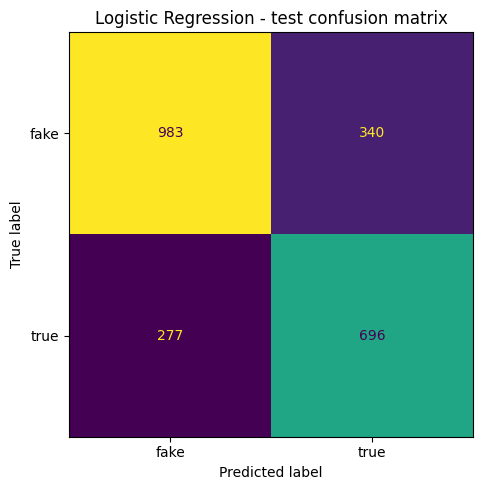

In [6]:
logreg_pipeline = Pipeline(
    steps=[
        ("preprocess", build_shared_preprocessor(existing_numeric_cols)),
        (
            "clf",
            LogisticRegression(
                solver="saga",
                max_iter=5000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logreg_params = {
    **shared_tfidf_space,
    "clf__C": [0.1, 0.5, 1.0, 2.0, 5.0],
    "clf__class_weight": [None, "balanced"],
}

logreg_artifacts = run_classical_model(
    name="Logistic Regression",
    pipeline=logreg_pipeline,
    param_distributions=logreg_params,
)

display(pd.DataFrame([{
    "model": "Logistic Regression",
    "best_cv_accuracy": logreg_artifacts["search"].best_score_,
    "best_params": json.dumps(logreg_artifacts["search"].best_params_, default=str),
}]))

plot_confusion_matrix_figure(
    y_true=y_test,
    y_pred=logreg_artifacts["test_result"]["predictions"],
    title="Logistic Regression - test confusion matrix",
)

## Classical model 2 — Linear SVC

Linear SVC is a linear Support Vector Machine classifier. It tries to find the decision boundary that best separates the classes, and it is often very effective for text data represented with TF-IDF.

This cell runs the same optimization and evaluation procedure, but with a linear support vector classifier.


Hyperparameter optimization for Linear SVC
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV accuracy for Linear SVC: 0.7189
{
  "preprocess__text__sublinear_tf": false,
  "preprocess__text__ngram_range": [
    1,
    2
  ],
  "preprocess__text__min_df": 1,
  "preprocess__text__max_features": 50000,
  "clf__class_weight": null,
  "clf__C": 0.1
}
Linear SVC | validation
--------------------------------------------------------------------------------
  accuracy: 0.7196
 precision: 0.6547
    recall: 0.7140
        f1: 0.6831
   roc_auc: 0.8015
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

        fake     0.7753    0.7238    0.7486      1325
        true     0.6547    0.7140    0.6831       972

    accuracy                         0.7196      2297
   macro avg     0.7150    0.7189    0.7159      2297
weighted avg     0.7243    0.7196    0.7209      2297

Linear SVC | test
-----

,model,best_cv_accuracy,best_params
0,Linear SVC,0.718928,"{""preprocess__text__sublinear_tf"": false, ""pre..."


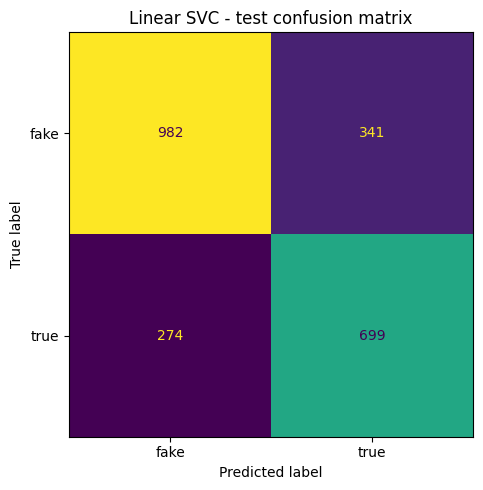

In [7]:
svc_pipeline = Pipeline(
    steps=[
        ("preprocess", build_shared_preprocessor(existing_numeric_cols)),
        (
            "clf",
            LinearSVC(
                max_iter=10_000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

svc_params = {
    **shared_tfidf_space,
    "clf__C": [0.1, 0.5, 1.0, 2.0, 5.0],
    "clf__class_weight": [None, "balanced"],
}

svc_artifacts = run_classical_model(
    name="Linear SVC",
    pipeline=svc_pipeline,
    param_distributions=svc_params,
)

display(pd.DataFrame([{
    "model": "Linear SVC",
    "best_cv_accuracy": svc_artifacts["search"].best_score_,
    "best_params": json.dumps(svc_artifacts["search"].best_params_, default=str),
}]))

plot_confusion_matrix_figure(
    y_true=y_test,
    y_pred=svc_artifacts["test_result"]["predictions"],
    title="Linear SVC - test confusion matrix",
)

## Classical model 3 — Multinomial Naive Bayes

Multinomial Naive Bayes is a probabilistic model based on word distributions. It is simple and fast, and although it makes strong independence assumptions, it often performs surprisingly well in text classification tasks.

This cell applies the same training and evaluation logic to Naive Bayes.


Hyperparameter optimization for MultinomialNB
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV accuracy for MultinomialNB: 0.7097
{
  "preprocess__text__sublinear_tf": true,
  "preprocess__text__ngram_range": [
    1,
    2
  ],
  "preprocess__text__min_df": 2,
  "preprocess__text__max_features": 100000,
  "clf__alpha": 0.5
}
MultinomialNB | validation
--------------------------------------------------------------------------------
  accuracy: 0.7040
 precision: 0.6130
    recall: 0.8148
        f1: 0.6996
   roc_auc: 0.7873
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

        fake     0.8209    0.6226    0.7082      1325
        true     0.6130    0.8148    0.6996       972

    accuracy                         0.7040      2297
   macro avg     0.7169    0.7187    0.7039      2297
weighted avg     0.7329    0.7040    0.7046      2297

MultinomialNB | test
------------------

,model,best_cv_accuracy,best_params
0,MultinomialNB,0.709728,"{""preprocess__text__sublinear_tf"": true, ""prep..."


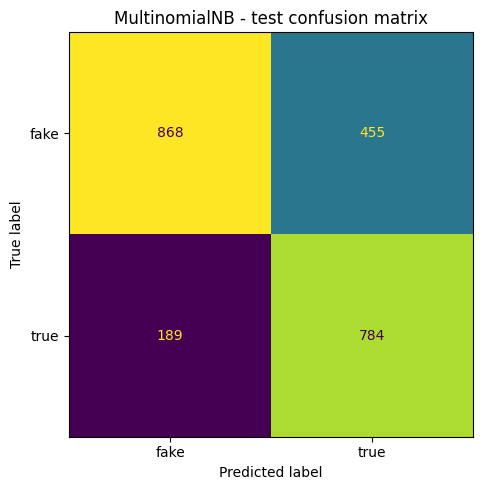

In [8]:
nb_pipeline = Pipeline(
    steps=[
        ("preprocess", build_shared_preprocessor(existing_numeric_cols)),
        ("clf", MultinomialNB()),
    ]
)

nb_params = {
    **shared_tfidf_space,
    "clf__alpha": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0],
}

nb_artifacts = run_classical_model(
    name="MultinomialNB",
    pipeline=nb_pipeline,
    param_distributions=nb_params,
)

display(pd.DataFrame([{
    "model": "MultinomialNB",
    "best_cv_accuracy": nb_artifacts["search"].best_score_,
    "best_params": json.dumps(nb_artifacts["search"].best_params_, default=str),
}]))

plot_confusion_matrix_figure(
    y_true=y_test,
    y_pred=nb_artifacts["test_result"]["predictions"],
    title="MultinomialNB - test confusion matrix",
)

## Summary of the classical models

This cell collects the tuned classical model results into tables and plots.

It gives a compact overview of:

- validation performance
- test performance

,model,best_cv_accuracy,best_params
0,Logistic Regression,0.719309,"{""preprocess__text__sublinear_tf"": true, ""prep..."
1,Linear SVC,0.718928,"{""preprocess__text__sublinear_tf"": false, ""pre..."
2,MultinomialNB,0.709728,"{""preprocess__text__sublinear_tf"": true, ""prep..."


,model,split,accuracy,precision,recall,f1,roc_auc
2,MultinomialNB,validation,0.703962,0.613003,0.814815,0.699647,0.787309
0,Logistic Regression,validation,0.723117,0.660920,0.709877,0.684524,0.799824
1,Linear SVC,validation,0.719634,0.654717,0.713992,0.683071,0.801505


,model,split,accuracy,precision,recall,f1,roc_auc
2,MultinomialNB,test,0.719512,0.632768,0.805755,0.708861,0.796108
1,Linear SVC,test,0.732143,0.672115,0.718397,0.694486,0.813508
0,Logistic Regression,test,0.731272,0.671815,0.715313,0.692882,0.811447


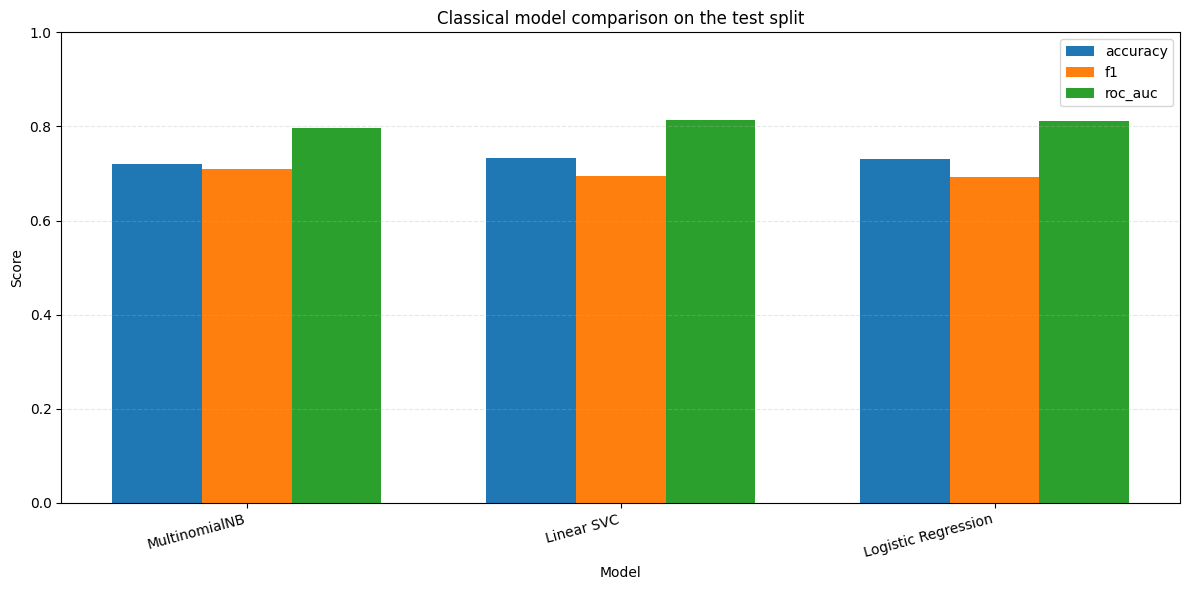

In [9]:
classical_artifacts = {
    "Logistic Regression": logreg_artifacts,
    "Linear SVC": svc_artifacts,
    "MultinomialNB": nb_artifacts,
}

classical_validation_rows = []
classical_test_rows = []
classical_best_params_rows = []

for model_name, artifacts in classical_artifacts.items():
    classical_validation_rows.append(
        {k: v for k, v in artifacts["validation_result"].items() if k not in {"report", "predictions", "scores"}}
    )
    classical_test_rows.append(
        {k: v for k, v in artifacts["test_result"].items() if k not in {"report", "predictions", "scores"}}
    )
    classical_best_params_rows.append(
        {
            "model": model_name,
            "best_cv_accuracy": artifacts["search"].best_score_,
            "best_params": json.dumps(artifacts["search"].best_params_, default=str),
        }
    )

classical_val_df = pd.DataFrame(classical_validation_rows)
classical_test_df = pd.DataFrame(classical_test_rows)
classical_best_params_df = pd.DataFrame(classical_best_params_rows)

display(classical_best_params_df)
display(classical_val_df.sort_values("f1", ascending=False))
display(classical_test_df.sort_values("f1", ascending=False))

plot_metric_bars(
    classical_test_df,
    title="Classical model comparison on the test split",
    filename="classical_test_metric_comparison.png",
)

## Deep learning section — DistilBERT

DistilBERT is a **transformer-based deep learning model** for natural language processing. It comes from the original **BERT** architecture, but it was made smaller through a technique called **knowledge distillation**, which transfers part of the knowledge of a larger model into a lighter one.

The main idea behind DistilBERT is to keep much of BERT’s language understanding ability while reducing computational cost. In practice, this makes it faster and easier to fine-tune than the original BERT, while still being strong for text classification tasks.

In this project, DistilBERT is not trained from scratch. Instead, we use a **pretrained checkpoint**, `distilbert-base-uncased`, which is already available in the **Hugging Face Transformers** library. This means that the model already knows general language patterns before seeing our dataset, and then it is **fine-tuned** on the fake news detection task.

The input used by DistilBERT is the `transformer_text` column, which contains the statement and other contextual fields organized as structured text. This text is tokenized and passed through the model, which produces two output scores, one for each class:

- `fake`
- `true`

So, in this notebook, DistilBERT is the **deep learning model** used to compare a pretrained transformer approach against the classical machine learning models.

In [10]:
def _optional_transformer_imports() -> Dict[str, Any]:
    import torch
    from datasets import Dataset
    from transformers import (
        AutoModelForSequenceClassification,
        AutoTokenizer,
        DataCollatorWithPadding,
        Trainer,
        TrainingArguments,
    )

    imports: Dict[str, Any] = {
        "torch": torch,
        "Dataset": Dataset,
        "AutoModelForSequenceClassification": AutoModelForSequenceClassification,
        "AutoTokenizer": AutoTokenizer,
        "DataCollatorWithPadding": DataCollatorWithPadding,
        "Trainer": Trainer,
        "TrainingArguments": TrainingArguments,
    }

    try:
        from transformers import EarlyStoppingCallback
        imports["EarlyStoppingCallback"] = EarlyStoppingCallback
    except Exception:
        imports["EarlyStoppingCallback"] = None

    return imports


imports = _optional_transformer_imports()

torch = imports["torch"]
Dataset = imports["Dataset"]
AutoModelForSequenceClassification = imports["AutoModelForSequenceClassification"]
AutoTokenizer = imports["AutoTokenizer"]
DataCollatorWithPadding = imports["DataCollatorWithPadding"]
Trainer = imports["Trainer"]
TrainingArguments = imports["TrainingArguments"]
EarlyStoppingCallback = imports["EarlyStoppingCallback"]

print("Transformer libraries imported successfully.")
print("CUDA available:", torch.cuda.is_available())

Transformer libraries imported successfully.
CUDA available: True


## Prepare the Hugging Face datasets

This notebook uses tools from the **Hugging Face ecosystem**, the `transformers` and `datasets` libraries.

The `datasets.Dataset` object is a data structure designed for machine learning workflows. It is similar in spirit to a dataframe because it stores data in columns, but it is more directly integrated with NLP pipelines and model training.

Tokenization is done by the **tokenizer** from the `transformers` library. The dataset is used to store the text and labels, and then the tokenizer is applied to it in a structured and efficient way.

This cell converts the pandas dataframes into Hugging Face datasets and tokenizes them. At the end, we print one tokenized example so that the transformation is visible.

In [11]:
def build_hf_dataset(dataset_cls: Any, text_series: pd.Series, labels: np.ndarray) -> Any:
    df = pd.DataFrame({"text": text_series.reset_index(drop=True), "label": labels})
    return dataset_cls.from_pandas(df, preserve_index=False)


def tokenize_hf_dataset(hf_dataset: Any, tokenizer: Any) -> Any:
    return hf_dataset.map(
        lambda batch: tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH),
        batched=True,
        remove_columns=["text"],
    )


tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL_NAME)

hf_train = build_hf_dataset(Dataset, train_df["transformer_text"], y_train)
hf_valid = build_hf_dataset(Dataset, valid_df["transformer_text"], y_valid)
hf_test = build_hf_dataset(Dataset, test_df["transformer_text"], y_test)
hf_train_valid = build_hf_dataset(
    Dataset,
    pd.concat([train_df["transformer_text"], valid_df["transformer_text"]], ignore_index=True),
    y_train_valid,
)

hf_train_tok = tokenize_hf_dataset(hf_train, tokenizer)
hf_valid_tok = tokenize_hf_dataset(hf_valid, tokenizer)
hf_test_tok = tokenize_hf_dataset(hf_test, tokenizer)
hf_train_valid_tok = tokenize_hf_dataset(hf_train_valid, tokenizer)

print("Tokenized sample:")
display(hf_train_tok[0])

Map:   0%|          | 0/18369 [00:00<?, ? examples/s]

Map:   0%|          | 0/2297 [00:00<?, ? examples/s]

Map:   0%|          | 0/2296 [00:00<?, ? examples/s]

Map:   0%|          | 0/20666 [00:00<?, ? examples/s]

Tokenized sample:


{'label': 1,
 'input_ids': [101,
  1031,
  4861,
  1033,
  3938,
  3867,
  1997,
  4841,
  1000,
  2490,
  5415,
  4281,
  14148,
  1000,
  2005,
  3282,
  17402,
  1012,
  1031,
  6123,
  1033,
  1037,
  1056,
  28394,
  2102,
  1031,
  3395,
  1033,
  2231,
  7816,
  1064,
  14592,
  1998,
  2270,
  5448,
  1064,
  4409,
  1031,
  5882,
  1033,
  3782,
  16768,
  2063,
  1031,
  2110,
  1033,
  5273,
  1031,
  16371,
  25531,
  1033,
  2995,
  1035,
  9294,
  1015,
  1025,
  3262,
  1035,
  2995,
  1035,
  9294,
  1018,
  1025,
  2431,
  1035,
  2995,
  1035,
  9294,
  1019,
  1025,
  3262,
  1035,
  6270,
  1035,
  9294,
  1017,
  1025,
  6270,
  1035,
  9294,
  1019,
  1025,
  6471,
  1035,
  2006,
  1035,
  2543,
  1035,
  9294,
  1016,
  1025,
  2095,
  2418,
  1025,
  3204,
  2184,
  102],
 'token_type_ids': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,

## Define the training helpers for DistilBERT

The next cell defines the small helper functions needed to train DistilBERT with the Hugging Face `Trainer`.


In [12]:
def compute_transformer_metrics_from_logits(
    logits: np.ndarray,
    labels: np.ndarray,
) -> Tuple[Dict[str, float], np.ndarray, np.ndarray]:
    scores = logits[:, 1]
    preds = np.argmax(logits, axis=1)
    metrics = compute_binary_metrics(labels, preds, scores)
    return metrics, preds, scores


def build_transformer_training_arguments(
    training_args_cls: Any,
    output_dir: Path,
    do_eval: bool,
    torch_module: Any,
) -> Any:
    signature = inspect.signature(training_args_cls.__init__)
    kwargs: Dict[str, Any] = {
        "output_dir": str(output_dir),
        "learning_rate": TRANSFORMER_LEARNING_RATE,
        "per_device_train_batch_size": TRANSFORMER_BATCH_SIZE if torch_module.cuda.is_available() else 8,
        "per_device_eval_batch_size": TRANSFORMER_BATCH_SIZE if torch_module.cuda.is_available() else 8,
        "num_train_epochs": TRANSFORMER_EPOCHS,
        "weight_decay": TRANSFORMER_WEIGHT_DECAY,
        "logging_strategy": "epoch",
        "save_total_limit": 1,
        "seed": RANDOM_STATE,
        "data_seed": RANDOM_STATE,
        "report_to": "none",
        "fp16": bool(torch_module.cuda.is_available()),
    }

    if do_eval:
        if "eval_strategy" in signature.parameters:
            kwargs["eval_strategy"] = "epoch"
        elif "evaluation_strategy" in signature.parameters:
            kwargs["evaluation_strategy"] = "epoch"

        kwargs["save_strategy"] = "epoch"
        kwargs["load_best_model_at_end"] = True
        kwargs["metric_for_best_model"] = "accuracy"
        kwargs["greater_is_better"] = True
    else:
        if "eval_strategy" in signature.parameters:
            kwargs["eval_strategy"] = "no"
        elif "evaluation_strategy" in signature.parameters:
            kwargs["evaluation_strategy"] = "no"

        kwargs["save_strategy"] = "no"
        kwargs["load_best_model_at_end"] = False

    return training_args_cls(**kwargs)


def build_transformer_trainer(
    trainer_cls: Any,
    model: Any,
    training_args: Any,
    train_dataset: Any,
    eval_dataset: Optional[Any],
    data_collator: Any,
    tokenizer: Any,
    compute_metrics_fn: Any,
    early_stopping_callback_cls: Optional[Any] = None,
) -> Any:
    trainer_signature = inspect.signature(trainer_cls.__init__)

    trainer_kwargs: Dict[str, Any] = {
        "model": model,
        "args": training_args,
        "train_dataset": train_dataset,
        "data_collator": data_collator,
        "compute_metrics": compute_metrics_fn,
    }

    if eval_dataset is not None:
        trainer_kwargs["eval_dataset"] = eval_dataset

    if "processing_class" in trainer_signature.parameters:
        trainer_kwargs["processing_class"] = tokenizer
    elif "tokenizer" in trainer_signature.parameters:
        trainer_kwargs["tokenizer"] = tokenizer

    callbacks: List[Any] = []
    if eval_dataset is not None and early_stopping_callback_cls is not None:
        callbacks.append(early_stopping_callback_cls(early_stopping_patience=1))
    if callbacks:
        trainer_kwargs["callbacks"] = callbacks

    return trainer_cls(**trainer_kwargs)


data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics_fn(eval_pred: Any) -> Dict[str, float]:
    logits, labels = eval_pred
    metrics, _, _ = compute_transformer_metrics_from_logits(logits, labels)
    return metrics

print("DistilBERT training helpers are ready.")

DistilBERT training helpers are ready.


## DistilBERT validation experiment

This cell fine-tunes DistilBERT on the training split and evaluates it on the validation split.

This is the step used to check whether the model is learning useful patterns before the final test training.

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.478765,0.408262,0.792338,0.720000,0.833333,0.772532,0.889783
2,0.379532,0.402321,0.800174,0.746398,0.799383,0.771982,0.894768


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


DistilBERT (distilbert-base-uncased) | validation
--------------------------------------------------------------------------------
  accuracy: 0.8002
 precision: 0.7464
    recall: 0.7994
        f1: 0.7720
   roc_auc: 0.8948
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

        fake     0.8447    0.8008    0.8222      1325
        true     0.7464    0.7994    0.7720       972

    accuracy                         0.8002      2297
   macro avg     0.7956    0.8001    0.7971      2297
weighted avg     0.8031    0.8002    0.8009      2297



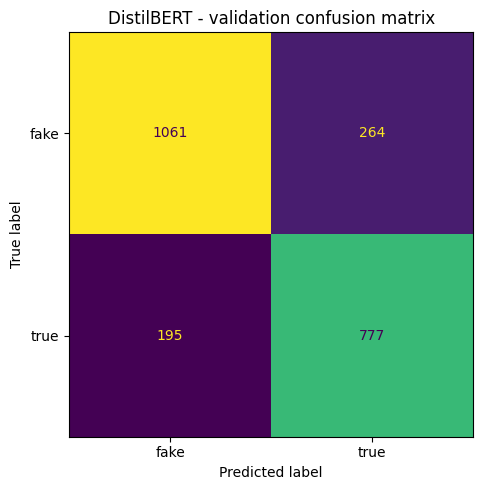

In [13]:
model_val = AutoModelForSequenceClassification.from_pretrained(
    TRANSFORMER_MODEL_NAME,
    num_labels=2,
    id2label={0: "fake", 1: "true"},
    label2id={"fake": 0, "true": 1},
)

val_args = build_transformer_training_arguments(
    training_args_cls=TrainingArguments,
    output_dir=OUTPUT_DIR / "distilbert_validation",
    do_eval=True,
    torch_module=torch,
)

trainer_val = build_transformer_trainer(
    trainer_cls=Trainer,
    model=model_val,
    training_args=val_args,
    train_dataset=hf_train_tok,
    eval_dataset=hf_valid_tok,
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics_fn=compute_metrics_fn,
    early_stopping_callback_cls=EarlyStoppingCallback,
)

trainer_val.train()

val_predictions = trainer_val.predict(hf_valid_tok)
distilbert_val_metrics, distilbert_val_preds, distilbert_val_scores = compute_transformer_metrics_from_logits(
    val_predictions.predictions,
    val_predictions.label_ids,
)

distilbert_val_report = classification_report(
    y_valid,
    distilbert_val_preds,
    target_names=["fake", "true"],
    digits=4,
    zero_division=0,
)

pretty_print_report(
    f"DistilBERT ({TRANSFORMER_MODEL_NAME})",
    "validation",
    distilbert_val_metrics,
    distilbert_val_report,
)

plot_confusion_matrix_figure(
    y_true=y_valid,
    y_pred=distilbert_val_preds,
    title="DistilBERT - validation confusion matrix",
)

## DistilBERT final test experiment

After validation, the model is trained again on `train + validation` and then evaluated on the test split.

This mirrors the final evaluation logic used for the classical models.

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
1292,0.469465
2584,0.380158


DistilBERT (distilbert-base-uncased) | test
--------------------------------------------------------------------------------
  accuracy: 0.8140
 precision: 0.7661
    recall: 0.8078
        f1: 0.7864
   roc_auc: 0.9060
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

        fake     0.8528    0.8186    0.8353      1323
        true     0.7661    0.8078    0.7864       973

    accuracy                         0.8140      2296
   macro avg     0.8094    0.8132    0.8109      2296
weighted avg     0.8160    0.8140    0.8146      2296



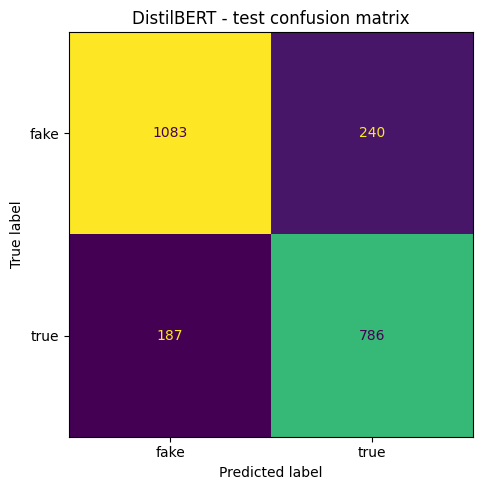

,model,split,accuracy,precision,recall,f1,roc_auc
0,DistilBERT (distilbert-base-uncased),validation,0.800174,0.746398,0.799383,0.771982,0.894768


,model,split,accuracy,precision,recall,f1,roc_auc
0,DistilBERT (distilbert-base-uncased),test,0.814024,0.766082,0.807811,0.786393,0.906015


In [14]:
model_test = AutoModelForSequenceClassification.from_pretrained(
    TRANSFORMER_MODEL_NAME,
    num_labels=2,
    id2label={0: "fake", 1: "true"},
    label2id={"fake": 0, "true": 1},
)

test_args = build_transformer_training_arguments(
    training_args_cls=TrainingArguments,
    output_dir=OUTPUT_DIR / "distilbert_test",
    do_eval=False,
    torch_module=torch,
)

trainer_test = build_transformer_trainer(
    trainer_cls=Trainer,
    model=model_test,
    training_args=test_args,
    train_dataset=hf_train_valid_tok,
    eval_dataset=None,
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics_fn=compute_metrics_fn,
    early_stopping_callback_cls=None,
)

trainer_test.train()

test_predictions = trainer_test.predict(hf_test_tok)
distilbert_test_metrics, distilbert_test_preds, distilbert_test_scores = compute_transformer_metrics_from_logits(
    test_predictions.predictions,
    test_predictions.label_ids,
)

distilbert_test_report = classification_report(
    y_test,
    distilbert_test_preds,
    target_names=["fake", "true"],
    digits=4,
    zero_division=0,
)

pretty_print_report(
    f"DistilBERT ({TRANSFORMER_MODEL_NAME})",
    "test",
    distilbert_test_metrics,
    distilbert_test_report,
)

plot_confusion_matrix_figure(
    y_true=y_test,
    y_pred=distilbert_test_preds,
    title="DistilBERT - test confusion matrix",
)

transformer_val_df = pd.DataFrame([{
    "model": f"DistilBERT ({TRANSFORMER_MODEL_NAME})",
    "split": "validation",
    **distilbert_val_metrics,
}])

transformer_test_df = pd.DataFrame([{
    "model": f"DistilBERT ({TRANSFORMER_MODEL_NAME})",
    "split": "test",
    **distilbert_test_metrics,
}])

display(transformer_val_df)
display(transformer_test_df)

try:
    del model_val, model_test, trainer_val, trainer_test
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
except Exception:
    pass

## Final comparison of all models

This final step combines the classical models and DistilBERT into a single comparison table.

,model,split,accuracy,precision,recall,f1,roc_auc
3,DistilBERT (distilbert-base-uncased),validation,0.800174,0.746398,0.799383,0.771982,0.894768
0,Logistic Regression,validation,0.723117,0.660920,0.709877,0.684524,0.799824
1,Linear SVC,validation,0.719634,0.654717,0.713992,0.683071,0.801505
2,MultinomialNB,validation,0.703962,0.613003,0.814815,0.699647,0.787309


,model,split,accuracy,precision,recall,f1,roc_auc
3,DistilBERT (distilbert-base-uncased),test,0.814024,0.766082,0.807811,0.786393,0.906015
1,Linear SVC,test,0.732143,0.672115,0.718397,0.694486,0.813508
0,Logistic Regression,test,0.731272,0.671815,0.715313,0.692882,0.811447
2,MultinomialNB,test,0.719512,0.632768,0.805755,0.708861,0.796108


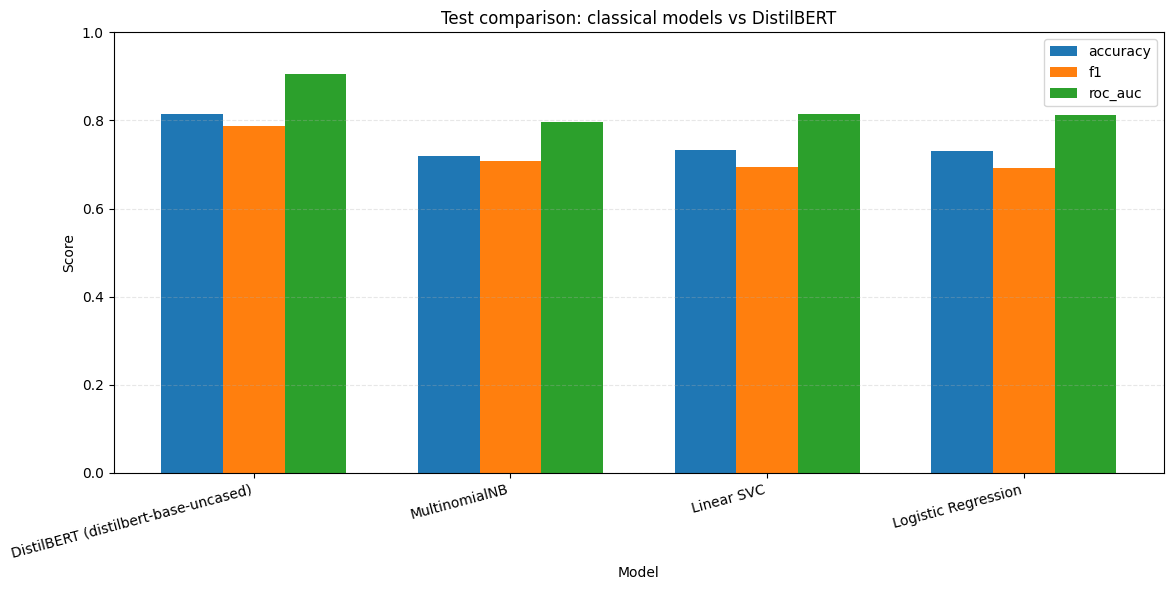


Best test model according to accuracy
--------------------------------------------------------------------------------
Model   : DistilBERT (distilbert-base-uncased)
Accuracy: 0.8140
F1      : 0.7864
ROC-AUC : 0.9060


In [15]:
combined_val_df = pd.concat([classical_val_df, transformer_val_df], ignore_index=True)
combined_test_df = pd.concat([classical_test_df, transformer_test_df], ignore_index=True)

display(combined_val_df.sort_values("accuracy", ascending=False))
display(combined_test_df.sort_values("accuracy", ascending=False))

plot_metric_bars(
    combined_test_df,
    title="Test comparison: classical models vs DistilBERT",
    filename="all_test_metric_comparison.png",
)

best_test_row = combined_test_df.sort_values("accuracy", ascending=False).iloc[0]

print("\nBest test model according to accuracy")
print("-" * 80)
print(f"Model   : {best_test_row['model']}")
print(f"Accuracy: {best_test_row['accuracy']:.4f}")
print(f"F1      : {best_test_row['f1']:.4f}")
print(f"ROC-AUC : {best_test_row['roc_auc']:.4f}")

## Conclusion

The results show that the deep learning approach, based on **DistilBERT**, achieved the best performance on both the validation and test sets, clearly outperforming the classical machine learning models in all main metrics. On the test split, DistilBERT reached an accuracy of **0.814**, an F1-score of **0.786**, and a ROC-AUC of **0.906**, while the classical models remained in the range of approximately **0.72 to 0.73** in accuracy and below **0.71** in F1-score. This indicates that the transformer-based model was better able to capture contextual and semantic information from the statements and their associated metadata, leading to more effective classification. However, this improvement comes at the cost of higher computational complexity, longer training time, and greater hardware requirements compared to the classical models, which are faster and simpler to train. Therefore, although the classical methods remain strong and efficient baselines, DistilBERT proved to be the most appropriate model for this task when predictive performance is the main priority.